In [4]:
from sklearn.datasets import load_wine
import pandas as pd

# data=load_breast_cancer()
# df=pd.DataFrame(data.data,columns=data.feature_names)
# df


data=load_wine()

df=pd.DataFrame(data.data,columns=data.feature_names)
df['target']=data.target
# df['target']
df.info()
df.describe()
df['target'].value_counts()
# df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

1    71
0    59
2    48
Name: target, dtype: int64

In [9]:
from sklearn.model_selection import train_test_split

x=df.drop('target',axis=1)
y=df['target']


x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(criterion='entropy',max_depth=2)
model.fit(x_train,y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=2)

In [11]:
y_pred=model.predict(x_test)

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

print("accuracy score:",accuracy_score(y_test,y_pred))
print("confusion matrix:\n",confusion_matrix(y_test,y_pred))
print("classification report:\n",classification_report(y_test,y_pred))


accuracy score: 0.9166666666666666
confusion matrix:
 [[14  0  0]
 [ 1 13  0]
 [ 2  0  6]]
classification report:
               precision    recall  f1-score   support

           0       0.82      1.00      0.90        14
           1       1.00      0.93      0.96        14
           2       1.00      0.75      0.86         8

    accuracy                           0.92        36
   macro avg       0.94      0.89      0.91        36
weighted avg       0.93      0.92      0.92        36



2 class


TP   FN
FP   TN


TP-- model pass     actual pass
fn---model Fail     Actual pAss
Fp---model pass    actual fail
TN===model fail    actual fail

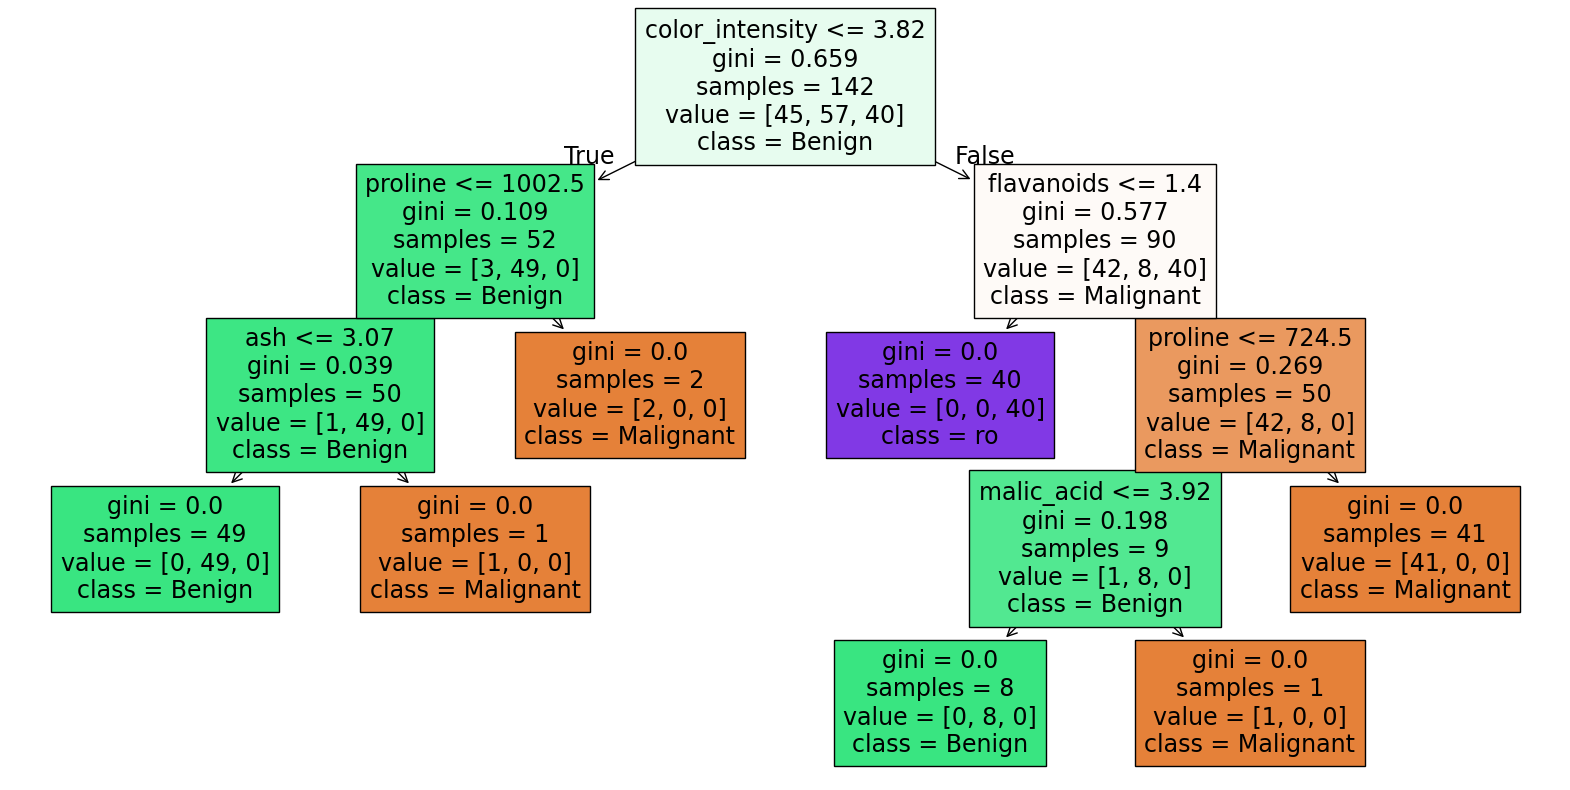

In [7]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
plot_tree(model,filled=True,
          feature_names=x.columns,
          class_names=['Malignant','Benign','ro'])
plt.show()

In [11]:
importances=model.feature_importances_
feature_df=pd.DataFrame({
    'Feature':x.columns,
    'Importance':importances
}).sort_values(by='Importance',ascending=False)
print(feature_df)

importances=model.feature_importances_
feature_df=pd.DataFrame({
    'Feature':x.columns,
    'Importance':importances

})
feature_df

                         Feature  Importance
6                     flavanoids    0.411053
9                color_intensity    0.384934
12                       proline    0.164075
2                            ash    0.020942
1                     malic_acid    0.018995
4                      magnesium    0.000000
3              alcalinity_of_ash    0.000000
0                        alcohol    0.000000
5                  total_phenols    0.000000
8                proanthocyanins    0.000000
7           nonflavanoid_phenols    0.000000
10                           hue    0.000000
11  od280/od315_of_diluted_wines    0.000000


,Feature,Importance
0,alcohol,0.000000
1,malic_acid,0.018995
2,ash,0.020942
3,alcalinity_of_ash,0.000000
4,magnesium,0.000000
5,total_phenols,0.000000
6,flavanoids,0.411053
7,nonflavanoid_phenols,0.000000
8,proanthocyanins,0.000000
9,color_intensity,0.384934


['Yes']


c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


,Age,Salary,Credit Score,Loan
0,25,20000,600,No
1,40,80000,750,Yes
2,35,50000,700,Yes
3,28,30000,650,No
4,50,90000,800,Yes


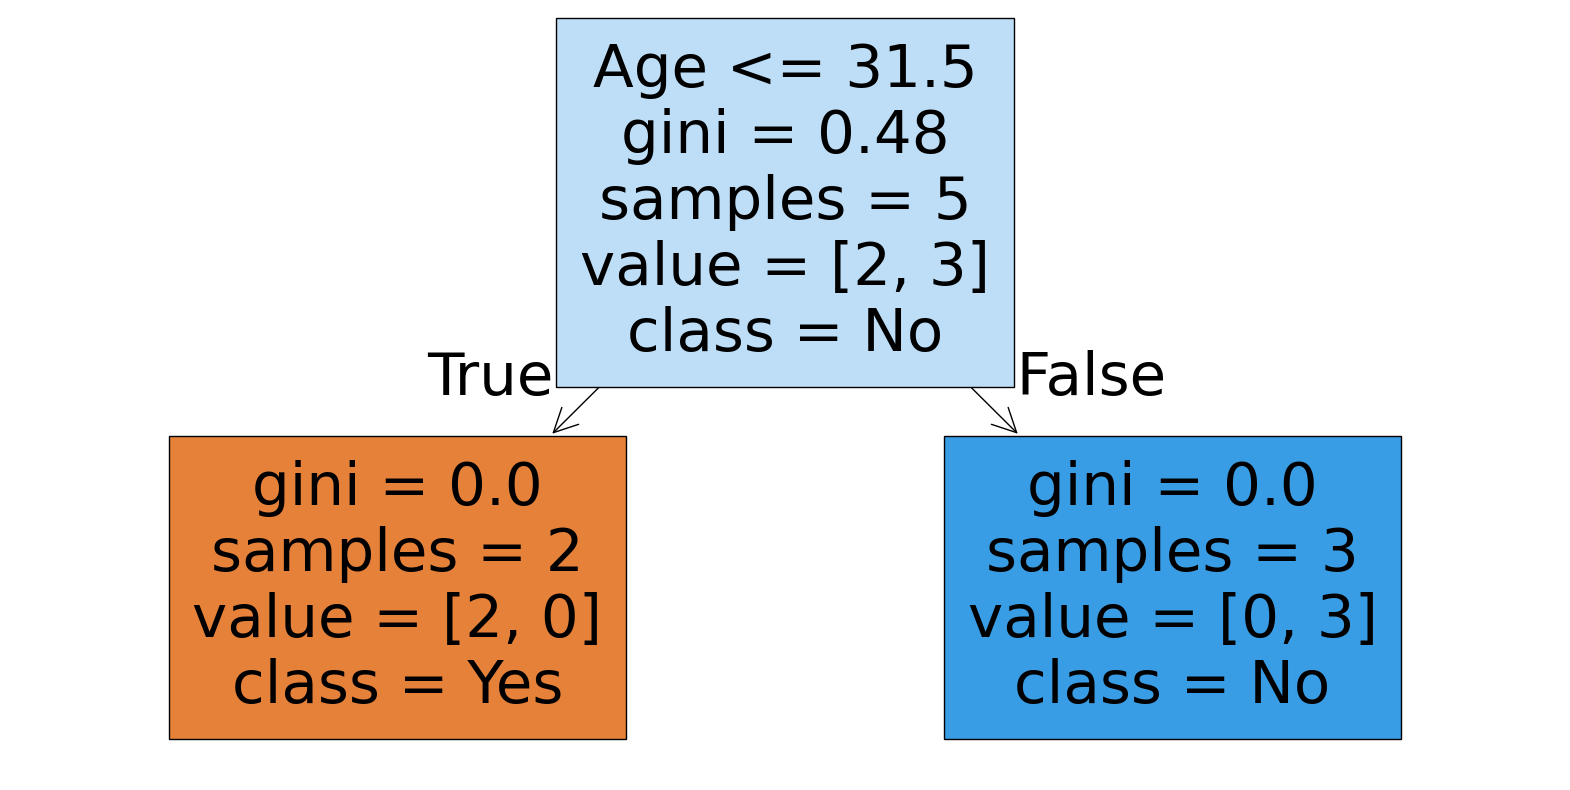

In [25]:
# | Age | Salary | Credit Score | Loan |
# | --- | ------ | ------------ | ---- |
# | 25  | 20000  | 600          | No   |
# | 40  | 80000  | 750          | Yes  |
# | 35  | 50000  | 700          | Yes  |
# | 28  | 30000  | 650          | No   |
# | 50  | 90000  | 800          | Yes  |



df=pd.DataFrame({
    'Age':[25,40,35,28,50],
    'Salary':[20000,80000,50000,30000,90000],
    'Credit Score':[600,750,700,650,800],
    'Loan':['No','Yes','Yes','No','Yes']
})

x=df[['Age','Salary','Credit Score']]
y=df['Loan']


from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(max_depth=1)
model.fit(x,y)

predictions=model.predict([[33,45000,700]])
print(predictions)


importances=model.feature_importances_
feature_df=pd.DataFrame({
    "Features":x.columns,
    'importance':importances
})
# print(feature_df)


from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model,feature_names=x.columns,filled=True,class_names=['Yes','No'])
df


In [13]:
# | Study Hours | Sleep Hours | Attendance | Pass |
# | ----------- | ----------- | ---------- | ---- |
# | 2           | 8           | 60         | No   |
# | 5           | 7           | 80         | Yes  |
# | 6           | 6           | 90         | Yes  |
# | 1           | 9           | 50         | No   |
# | 4           | 6           | 70         | Yes  |




import pandas as pd

df=pd.DataFrame({
    "Study_Hours":[2,5,6,1,4],
    "Sleep_Hours":[8,7,6,9,6],
    "Attendance":[60,80,90,50,70],
    "Result":["Fail",'Pass','Pass','Fail','Pass']
})
df


x=df.drop('Result',axis=1)
y=df['Result']


from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(max_depth=3,criterion='entropy')
model.fit(x,y)

from sklearn.metrics import accuracy_score

y_pred=model.predict(x)

predictions=model.predict([[2,8,90]])
print(predictions)


print("Accuracy Score:",accuracy_score(y,y_pred))


# from sklearn.tree import plot_tree
# import matplotlib.pyplot as plt

# plt.figure(figsize=(20,10))
# plot_tree(model,filled=True,feature_names=x.columns,class_names=['Pass','Fail'])


importances=model.feature_importances_
feature_df=pd.DataFrame({
    "Features":[x.columns],
    'Importances':[importances]
})
feature_df

['Fail']
Accuracy Score: 1.0


c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


,Features,Importances
0,"Index(['Study_Hours', 'Sleep_Hours', 'Attendan...","[0.0, 1.0, 0.0]"


In [67]:
import pandas as pd

df=pd.read_csv('titanic.csv')
df=df[['Pclass','Age','Fare','Sex','Survived']]

df.isnull().sum()

df['Age'].fillna(df['Age'].mean(),inplace=True)
df['Sex']=df['Sex'].map({'male':0,'female':1})


x=df.drop('Survived',axis=1)
y=df['Survived']


from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


from sklearn.tree import DecisionTreeClassifier

model=DecisionTreeClassifier(max_depth=6,criterion='gini',min_samples_split=10,min_samples_leaf=6)
model.fit(x_train,y_train)


from sklearn.metrics import accuracy_score,confusion_matrix

y_pred=model.predict(x_test)

print("Accuracy Score:",accuracy_score(y_test,y_pred))
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred))


# from sklearn.tree import plot_tree
# import matplotlib.pyplot as plt


# plt.Figure(figsize=(10,20))
# plot_tree(model,filled=True,feature_names=x.columns,class_names=['Not Survived','Survived'])
# plt.show()


print("Training:",model.score(x_train,y_train))
print("Testing:",model.score(x_test,y_test))


Accuracy Score: 0.8324022346368715
Confusion Matrix:
 [[94 11]
 [19 55]]
Training: 0.8553370786516854
Testing: 0.8324022346368715


C:\Users\Administrator\AppData\Local\Temp\ipykernel_13744\3009240721.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [2]:
# Auto Tunning
# GridSearchCV


import pandas as pd

df=pd.read_csv('titanic.csv')
df=df[['Pclass','Age','Fare','Sex','Survived']]

df.isnull().sum()

df['Age'].fillna(df['Age'].mean(),inplace=True)
df['Sex']=df['Sex'].map({'male':0,'female':1})


x=df.drop('Survived',axis=1)
y=df['Survived']


from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

# paramas grid

params={
    'max_depth':[2,3,4,5,6,7],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,5,10],
    'criterion':['gini','entropy']
}


dt=DecisionTreeClassifier()


# grid search 
grid=GridSearchCV(dt,params,cv=5,scoring='accuracy',n_jobs=-1)

grid.fit(x_train,y_train)

print("Best Params:",grid.best_params_)
print("Best Score:",grid.best_score_)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_2340\1565104666.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


Best Params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best Score: 0.8173840244262779


In [4]:
best_model = grid.best_estimator_

print("Train:", best_model.score(x_train, y_train))
print("Test:", best_model.score(x_test, y_test))

Train: 0.827247191011236
Test: 0.7988826815642458


experience,salary,hour worked    target hire,no hire


entropy,gini
max_depth=3